
# <span style="color:rgb(213,80,0)">Primer examen parcial \- Robótica </span>

Rodríguez Rinconcillo Diego

## Introducción

En este reporte se presentan los planteamientos de los modelos solicitados como parte del primer examen parcial de la materia de Robótica de la Facultad de Ingeniería de la UNAM. Estos modelos fueron desarrollados con base en los conocimientos adquiridos durante el transcurso del curso. Se utilizaron grabaciones de clases pasadas como referencia \[1, 2\] y la IA Gemini únicamente para la revisión de ortografía y redacción \[3\].


A continuación, se presenta una descripción básica del robot para el cual se van a generar los modelos a lo largo del presente reporte. Se trata de un robot manipulador con una topología del tipo RRR planar, puesto que contamos con tres juntas rotacionales contenidas en el mismo plano. Este es un robot definido, ya que los grados de libertad del mismo (3 DOF) son los mismos que necesitamos para describir la posición y orientación del efector final.


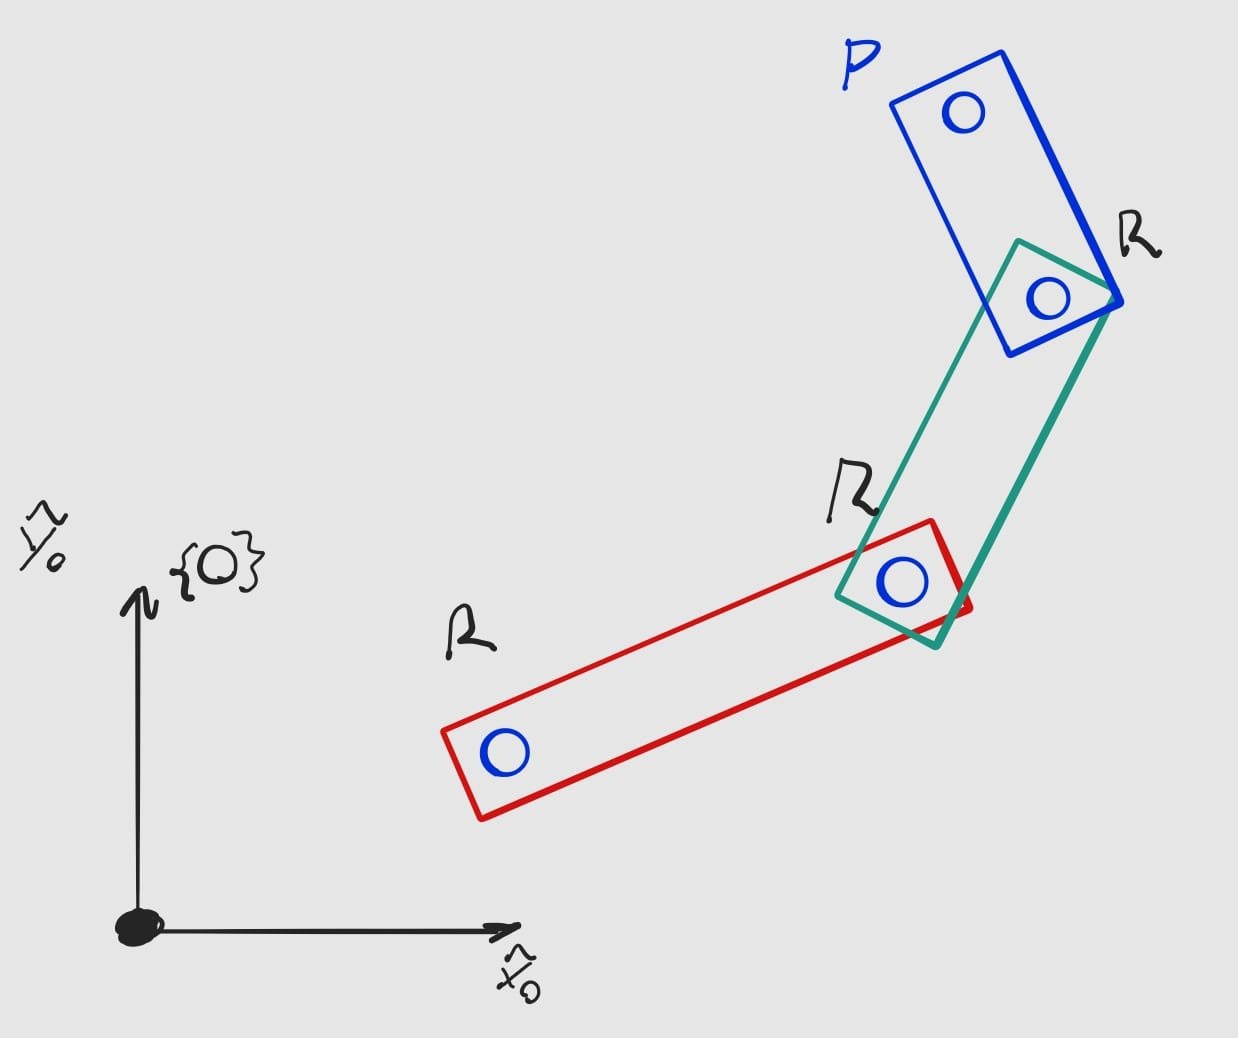


**Hipótesis**:


Si los modelos matemáticos cinemáticos de posición, velocidad y aceleración directos e indirectos y el modelo dinámico directo e indirecto son herramientas que permiten predecir el comportamiento de un robot manipulador, entonces al plantearlos se puede conocer su viabilidad de funcionamiento previo a la simulación del mismo.


**Objetivo General:**


Plantear los modelos matemáticos de cinemática y dinámica directos e indirectos para un robot manipulador con el fin de conocer el comportamiento del mismo para simular posteriormente.


**Objetivos específicos:**

-  Plantear el modelo cinemático directo e inverso de postura para un robot manipulador con el fin de obtener los ángulos del efector final en base en los ángulos de las juntas rotacionales para el modelo directo y viceversa para el modelo indirecto.
-  Construir el modelo cinemático directo e inverso de las velocidades para un robot manipulador con el fin de conocer la velocidad del efector final según las velocidades conocidas de las juntas rotacionales para el modelo directo y conocer las velocidades de las articulaciones necesarias para conseguir una velocidad específica del efector final.
-  Elaborar el modelo cinemático directo e inverso de aceleración para un robot manipulador con el fin de obtener la aceleración en el efector final según las aceleraciones de las articulaciones en el modelo directo o viceversa para el modelo indirecto.
-  Generar el modelo dinámico directo e inverso para un robot manipulador por el método de Euler\-Lagrange.
## Modelado cinemático de la postura

El método que se va a seguir para obtener el siguiente modelo es sustraer el vector de postura de la matriz de transformación homogénea. En esta se contienen la matriz de rotación, el vector de posición, un factor de escala que para fines de este planteamiento será unitario, y un vector nulo transpuesto. Estos efectos son vistos desde el efector final, que llamaremos P, respecto a nuestra tierra 0.


$$^0 T_P =\left(\begin{array}{cc} ^0 R_P  & ^0 p_P \newline 0^T  & 1 \end{array}\right)$$

Para el cálculo de esta matriz primero se colocaron sistemas de referencia en cada una de nuestras juntas rotacionales y en nuestros puntos P y 0.


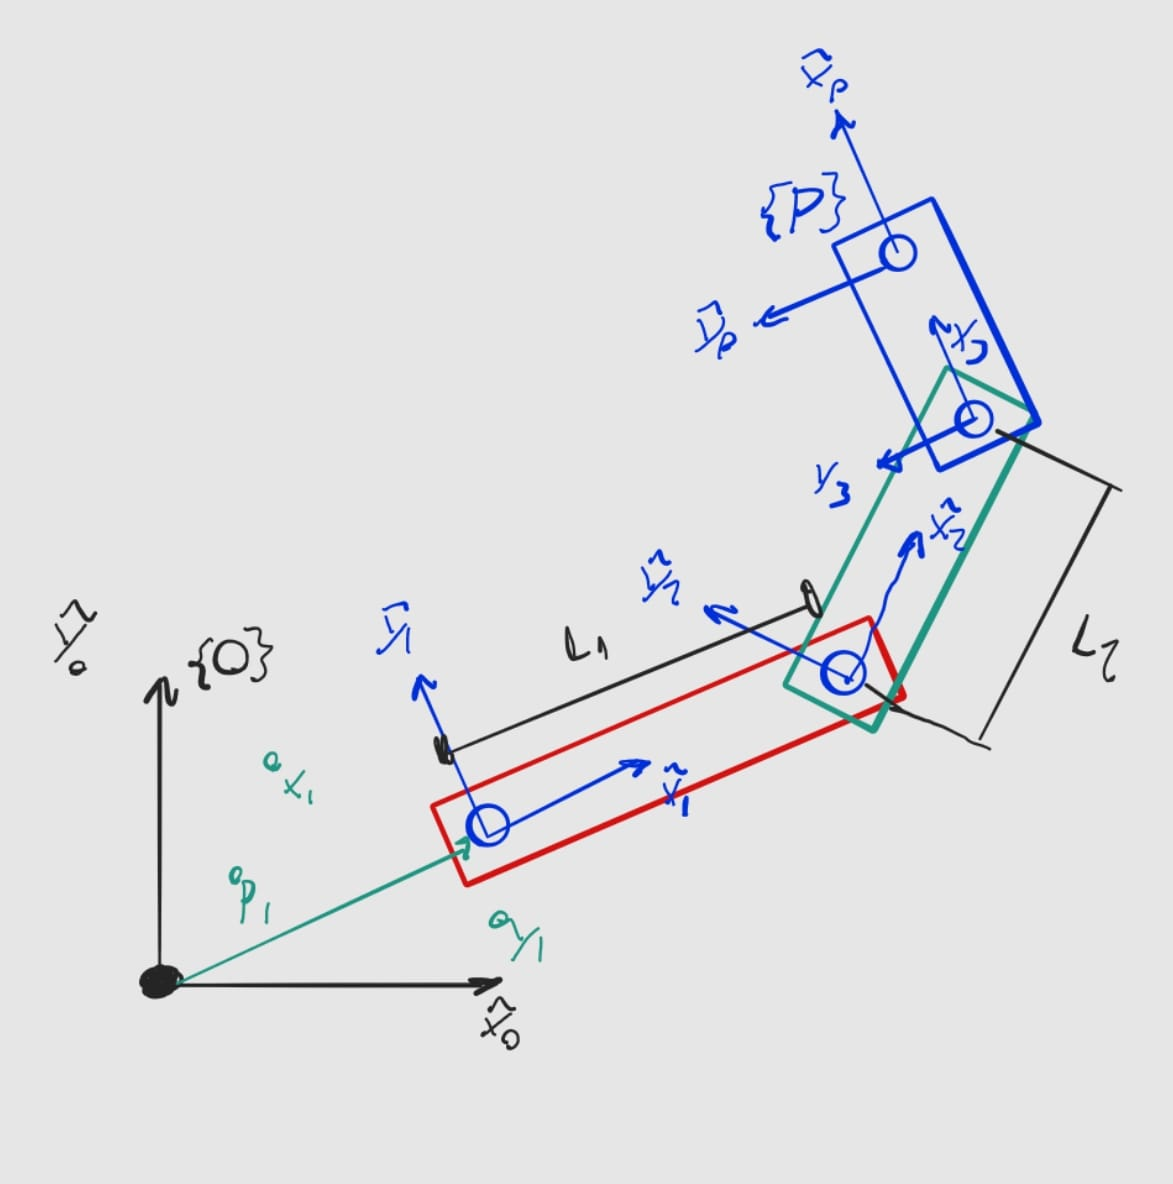


A partir de estos, se definieron las matrices de traslación homogéneas necesarias para transferir los efectos desde el punto P a nuestra tierra, como se muestra en la siguiente ecuación.


$$^0 T_P =^0 T_1 ^1 T_2 ^2 T_3 ^3 T_P$$

Función de transfomración en el plano.


In [1]:
%Deficición de la función de manera simbolica
syms Tij(x_i_j,y_i_j,z_i_j,gi_j,bi_j,ai_j)

%Definición de la transformación homógenea general
Tij(x_i_j,y_i_j,z_i_j,gi_j,bi_j,ai_j) = [cos(ai_j)*cos(bi_j) cos(ai_j)*sin(bi_j)*sin(gi_j)-sin(ai_j)*cos(gi_j) sin(ai_j)*sin(gi_j)+cos(ai_j)*sin(bi_j)*cos(gi_j) x_i_j; sin(ai_j)*cos(bi_j) cos(ai_j)*cos(gi_j)+sin(ai_j)*sin(bi_j)*sin(gi_j) sin(ai_j)*sin(bi_j)*cos(gi_j)-cos(ai_j)*sin(gi_j) y_i_j; -sin(bi_j) cos(bi_j)*sin(gi_j) cos(bi_j)*cos(gi_j) z_i_j; 0 0 0 1]


Donde

-  $^0 T_1$  :

In [2]:
syms x_O_1 y_O_1 theta_O_1 L_2 theta_1_2 L_3 theta_2_3 L_1

T_O_1 = Tij(x_O_1,y_O_1,0,0,0,theta_O_1)

-  $^1 T_2$ :

In [3]:
T_1_2 = Tij(L_1,0,0,0,0,theta_1_2)

-  $^2 T_3$ :

In [4]:
T_2_3 = Tij(L_2,0,0,0,0,theta_2_3)

-  $^3 T_P$ :

In [5]:
T_3_P = Tij(L_3,0,0,0,0,0)


Por lo tanto nuestra matriz de transferencia general es la siguiente:


In [6]:
T_O_P = simplify(T_O_1*T_1_2*T_2_3*T_3_P)


De donde podemos finalmente obtener nuestro modelo de la postura.


In [7]:
xi_O_P = [T_O_P(1,4);T_O_P(2,4);theta_O_1+theta_1_2+theta_2_3]


Nótese que se está utilizando el modelo donde se visualiza cada elemento del vector como una función dependiente de los ángulos de nuestro sistema. Esto con la finalidad de poder realizar los cálculos pertinentes para obtener los siguientes modelos.


$$F=^o \xi_p -^o \xi_p (q)=0\Longrightarrow ^o \xi_p =^o \xi_p (q)$$
## Modelo cinemático inverso de la postura

Debido a que el modelo directo obtenido no es una matriz cuadrada para obtener su inversa se propone el uso del método de pseudoinversa de Moore\-Penrose (por izquierda debido a que la matriz contiene más filas que columnas).


$$A^+ ={\left(A^T A\right)}^{-1} A^T$$

Comenzamos por calcular la matriz transpuesta.


In [8]:
AT = transpose(xi_O_P);


Obtenemos ${\left(A^T A\right)}^{-1}$ .


In [9]:
Atemporal = (AT*xi_O_P)^(-1);


 Por último realizamos el cálculo para obtener nuestro modelo inverso de la postura.


In [10]:
inv_xi_O_P = Atemporal*transpose(xi_O_P)

## Modelo cinemático directo de las velocidades

Para obtener el modelo cinemático directo de las velocidades partimos del modelo directo de la postura.


$$^o \xi_p =^o \xi_p (q)$$

Posteriormente, aplicamos operador derivada total a ambos miembros del modelo.


$$\frac{d}{dt}^o \xi_p =\frac{d}{dt}^o \xi_p (q)$$

Desarrollando $\frac{d}{dt}^0 \xi_p (q)$ obtenemos la siguiente equación por derivadas parciales.


$$\frac{d}{dt}^o \xi_p (q)=\frac{\partial }{\partial ^o \theta_1 }^o \xi_p (q)^o {\dot{\theta} }_1 +\frac{\partial }{\partial ^1 \theta_2 }^o \xi_p (q)^1 {\dot{\theta} }_2 +\frac{\partial }{\partial ^2 \theta_3 }^o \xi_p (q)^2 {\dot{\theta} }_3$$

De lo anterior podemos factorizar el vector de las velocidades.


$$\frac{d}{dt}^o \xi_p (q)=\left(\frac{\partial }{\partial ~^o \theta_1 }^o \xi_P (q)~~\frac{\partial }{\partial ~^1 \theta_2 }^o \xi_P (q)~~\frac{\partial }{\partial ~^2 \theta_3 }^o \xi_P (q)\right) \left(\begin{array}{c} ^o {\dot{\theta} }_1 \newline ^1 {\dot{\theta} }_2 \newline ^2 {\dot{\theta} }_3  \end{array}\right)$$

Por lo que podemos representar el modelo de la siguiente forma.

\matlabheadingtwo{
$$^o {\dot{\xi} }_P =J_{\theta } (q)\dot{q}$$}

Donde $J_{\theta } (q)$ es la siguiente matriz. Nótese que cada columna de la matriz jacobiana obtenida representa la proyección de los efectos de la velocidad de cada junta rotacional proyectados en el efector final.


In [11]:
syms J_theta

J_theta

In [12]:
J_theta = jacobian(xi_O_P,[theta_O_1, theta_1_2,theta_2_3])

## Modelo cinemático inverso de las velocidades

Puesto que se está trabajando con un robot del tipo definido, el despeje de la matriz jacobiana se puede realizar simplemente calculando su matriz inversa. Sin embargo, este es un caso especial, ya que si estuviéramos trabajando con uno infraactuado o sobreactuado, tendríamos que realizar los despejes con la pseudoinversa de la matriz jacobiana.

\matlabheadingtwo{
$$\dot{q} ={J_{\theta } }^{-1} (q)~^o {\dot{\xi} }_P$$}

Donde el vector $^0 {\dot{\xi} }_P$ tiene como entradas las velocidades lineales y angulares del efector final.


$$^o {\dot{\xi} }_P =\left(\begin{array}{c} ^o {\dot{x} }_P \newline ^o {\dot{y} }_P \newline ^o {\dot{\theta} }_P  \end{array}\right)$$

Y donde ${J_{\theta } }^{-1} (q)$ es la siguiente matriz.


In [13]:
inv(J_theta)

## Modelo cinemático de las aceleraciones

Para obtener este modelo podemos partir del modelo cinemático de las velocidades.


$$^o {\dot{\xi} }_P =J_{\theta } (q)\dot{q}$$

Nuevamente, aplicamos operador derivada total a ambos miembros del modelo.


$$\frac{d}{dt}^o {\dot{\xi} }_p =\frac{d}{dt}\left({J_{\theta } }(q)\dot{q} \right)$$

Desarrollando el lado derecho de la equación.


$$\frac{d}{dt}\left({J_{\theta } }(q)\dot{q} \right)={\dot{J} }_{\theta } (q,\dot{q} )\dot{q} +J_{\theta } (q)\ddot{q}$$


Por lo tanto, podemos concluir que el modelo cinemático de las aceleraciones es el siguiente.

\matlabheadingtwo{
$$^o {\ddot{\xi} }_P ={\dot{J} }_{\theta } (q,\dot{q} )\dot{q} +J_{\theta } (q)\ddot{q}$$}

Donde:

-      $\displaystyle \ddot{q} =\left(\begin{array}{c} ^0 {\ddot{\theta} }_1 \newline ^1 {\ddot{\theta} }_2 \newline ^2 {\ddot{\theta} }_3  \end{array}\right)$
-  $\displaystyle {\dot{J} }_{\theta } (q,\dot{q} )=H_{\theta } (q,\dot{q} )$

   Por último, calculamos a matriz hessiana $H_{\theta } (q,\dot{q} )$ .


In [14]:
syms theta_O_1 theta_1_2 theta_2_3

H_l_1 = hessian(xi_O_P(1,:),[theta_O_1, theta_1_2, theta_2_3])

## Modelo cinemático inverso de las aceleraciones

¡De acuerdo! Aquí tienes la revisión:


Por fines de simplicidad, la estrategia que se tomó para calcular este modelo es partir del modelo cinemático inverso de las velocidades y aplicar derivada total a ambos miembros de la ecuación.


$$\frac{d}{dt}\dot{q} =\frac{d}{dt}\left({J_{\theta } }^{-1} (q)~^o {\dot{\xi} }_P \right)$$

Por regla de la cadena obtenemos lo siguiente.


$$\frac{d}{dt}\left({J_{\theta } }^{-1} (q)~^o {\dot{\xi} }_P \right)=\frac{d}{dt}\left({J_{\theta } }^{-1} (q)\right)^o {\dot{\xi} }_P +{J_{\theta } }^{-1} \frac{d}{dt}\left(^o {\dot{\xi} }_P \right)$$

Desarrollamos el término  $\frac{d}{dt}{J_{\theta } }^{-1} (q)$ y lo sustituímos en nuestra ecuación.


$$\frac{d}{dt}{J_{\theta } }^{-1} (q)=\ddot{q} =-J_{\theta }^{-1} (q){\dot{J} }_{\theta } (q,\dot{q} )J_{\theta }^{-1} (q)$$

$$\ddot{q} =-J_{\theta }^{-1} (q){\dot{J} }_{\theta } (q,\dot{q} )J_{\theta }^{-1} (q)^o {\dot{\xi} }_P +J_{\theta }^{-1} (q)^o {\ddot{\xi} }_P$$

Para finalizar, simplificamos y obtenemos el modelo cinemático inverso de las aceleraciones.


$$\ddot{q} =-J_{\theta }^{-1} (q){\dot{J} }_{\theta } (q,\dot{q} )\dot{q} +J_{\theta }^{-1} (q)^o {\ddot{\xi} }_P$$
## Modelo dinámico por ecuaciones de Eüler\-Lagrange
### Cálculo de la posición de los centros de masa

A continuación hacemos el cálculo de la posición de los centros de masa haciendo uso de la función de transformación homogénea que definimos en el primer modelo.


Transformación ${}^{\mathrm{1}}{\mathbf{T}}_{\textrm{C1}}$


In [15]:
syms x_1_C1 x_2_C2 x_3_C3

T_1_C1 = Tij(x_1_C1,0,0,0,0,0)


Transformación ${}^0{\mathbf{T}}_{\textrm{C1}}$


In [16]:
T_O_C1 = T_O_1*T_1_C1


Transformación ${}^2{\mathbf{T}}_{\textrm{C2}}$


In [17]:
T_2_C2 = Tij(x_2_C2,0,0,0,0,0)


Transformación ${}^0{\mathbf{T}}_{\textrm{C2}}$


In [18]:
T_O_C2 = T_O_1*T_1_2*T_2_C2


Transformación ${}^3{\mathbf{T}}_{\textrm{C3}}$


In [19]:
T_3_C3 = Tij(x_3_C3,0,0,0,0,0)


Transformación ${}^0{\mathbf{T}}_{\textrm{C3}}$


In [20]:
T_O_C3 = simplify(T_O_1*T_1_2*T_2_3*T_3_C3)


De las matrices anteriores podemos obtener los vectores de posición de cada centro de masa respecto al sistema 0.


In [21]:
%Vectores de posición
p_O_C1 = [T_O_C1(1,4);T_O_C1(2,4);T_O_C1(3,4)]

In [22]:
p_O_C2 = simplify([T_O_C2(1,4);T_O_C2(2,4);T_O_C2(3,4)])

In [23]:

p_O_C3 = simplify([T_O_C3(1,4);T_O_C3(2,4);T_O_C3(3,4)])

### Cálculo de las velocidades lineales

Debido a que la posición de los centros de masa ya fue calculada y que se está haciendo uso del método de Euler\-Lagrange, donde el análisis se realiza respecto a energías y no a fuerzas y momentos, podemos utilizar la siguiente fórmula para el cálculo de estas velocidades.


$${}^0{\mathbf{v}}_{\mathrm{Ci}}=\frac{\mathrm{d}}{\mathrm{dt}}{}^0{\mathbf{p}}_{\mathrm{Ci}}=\frac{\mathrm{d}}{\mathrm{d}\theta_{O,1} }{}^0{\mathbf{p}}_{\mathrm{Ci}}+\frac{\mathrm{d}}{\mathrm{d}\theta_{1,2} }{}^0{\mathbf{p}}_{\mathrm{Ci}}+\frac{\mathrm{d}}{\mathrm{d}\theta_{2,3} }{}^0{\mathbf{p}}_{\mathrm{Ci}}$$

In [24]:
syms theta_dot_O_1 theta_dot_1_2 theta_dot_2_3

v_O_C1 = simplify(diff(p_O_C1,theta_O_1)*theta_dot_O_1+diff(p_O_C1,theta_1_2)*theta_dot_1_2+diff(p_O_C1,theta_2_3)*theta_dot_2_3)

In [25]:
v_O_C2 = simplify(diff(p_O_C2,theta_O_1)*theta_dot_O_1+diff(p_O_C2,theta_1_2)*theta_dot_1_2+diff(p_O_C2,theta_2_3)*theta_dot_2_3)

In [26]:
v_O_C3 = simplify(diff(p_O_C3,theta_O_1)*theta_dot_O_1+diff(p_O_C3,theta_1_2)*theta_dot_1_2+diff(p_O_C3,theta_2_3)*theta_dot_2_3)

### Cálculo de la velocidades angulares

Para este cálculo se va a hacer uso de la fórmula de propagación de veocudades angulares.


$$^{i+1} \omega_{i+1} =^{i+1} R_i ^i \omega_i +^{i+1} {\hat{z} }_{i+1} {\dot{\theta} }_{i+1}$$

Nótese que la fórmula hace uso de matrices de rotación que no se han calculado, pero recordando la siguiente propiedad de las matrices, podemos hacer uso de la matriz transpuesta de una ya conocida.


$${}^1{\mathbf{R}}_0={{}^0{\mathbf{R}}_1}^{-1} ={{}^0{\mathbf{R}}_1}^T$$

-  Propagación de velocidades angulares del primer cuerpo:

In [27]:
syms omega_1_1 omega_2_2 omega_3_3
%Propagación para el primer cuerpo
omega_1_1


Debido a que no contamos con velocidad angular en el punto 0 podemos definirla como un vector nulo.


In [28]:
omega_O_O = [0;0;0]

omega_O_O = 3x1
     0
     0
     0


Procedemos a hacer las definiciones del eje de rotación, la matriz de rotación y su transpuesta.


In [29]:
n_1_1 = [0;0;1]

n_1_1 = 3x1
     0
     0
     1

In [30]:
R_O_1 = [T_O_1(1,1),T_O_1(1,2),T_O_1(1,3);T_O_1(2,1),T_O_1(2,2),T_O_1(2,3);T_O_1(3,1),T_O_1(3,2),T_O_1(3,3)]

In [31]:
R_1_O = transpose(R_O_1)


Por último realizamos el cálculo de la velocidad angular del primer eslabón.


In [32]:
%Ecuación de propagación
omega_1_1 = R_1_O*omega_O_O+n_1_1*theta_dot_O_1

-  Propagación de velocidades angulares del segundo cuerpo:

A continuación repetimos el procedimiento para el segundo eslabón de nuestra cadena cinemática.


In [33]:
n_2_2 = [0;0;1]

n_2_2 = 3x1
     0
     0
     1

In [34]:
R_1_2 = [T_1_2(1,1),T_1_2(1,2),T_1_2(1,3);T_1_2(2,1),T_1_2(2,2),T_1_2(2,3);T_1_2(3,1),T_1_2(3,2),T_1_2(3,3)]

In [35]:
R_2_1 = transpose(R_1_2)

In [36]:
%Ecuación de propagación
omega_2_2 = R_2_1*omega_1_1+n_2_2*theta_dot_1_2

-  Propagación de velocidades angulares del tercer cuerpo:

Por último, podemos realizar el procedimiento para obtener la velocidad angular del tercer eslabón repitiendo los pasos anteriores con los cambios pertinentes.


In [37]:
n_3_3 = [0;0;1]

n_3_3 = 3x1
     0
     0
     1

In [38]:
R_2_3 = [T_2_3(1,1),T_2_3(1,2),T_2_3(1,3);T_2_3(2,1),T_2_3(2,2),T_2_3(2,3);T_2_3(3,1),T_2_3(3,2),T_2_3(3,3)]

In [39]:
R_3_2 = transpose(R_2_3)

In [40]:

%Ecuación de propagación
omega_3_3 = R_3_2*omega_2_2+n_3_3*theta_dot_2_3

### Defición de los elementos de inercia

Para finalizar procedemos a definir las matrices de inercia correspondientes a cada eslabón. Además, definimos el vector de gravedad en el eje que le corresponde.


In [41]:
syms g I_xx1 I_yy1 I_zz1 I_xx2 I_yy2 I_zz2 I_xx3 I_yy3 I_zz3
%vector de gravedad

g_v = [0;-g;0]

In [42]:
I_C1 = [I_xx1,0,0;0,I_yy1,0;0,0,I_zz1]

In [43]:
I_C2 = [I_xx2,0,0;0,I_yy2,0;0,0,I_zz2]

In [44]:
I_C3 = [I_xx3,0,0;0,I_yy3,0;0,0,I_zz3]

### Cálculo de las energías cinéticas y potenciales

Ya con todos los elementos de las fórmulas de energía definidos podemos proceder a hacer los cálculos de estas para cada eslabón.


Fórmula de la energía cinética: $k=\frac{1}{2}m_1 {\mathbf{v}}_{\mathrm{C1}}^T {\mathbf{v}}_{\mathrm{C1}} +\frac{1}{2}{{}^1{\omega }_1}^T {\mathrm{I}}_{\mathrm{C1}} {}^1{\omega }_1$

-  Energía cinética del primer cuerpo:

In [45]:
syms m_1 m_2 m_3
%energía cinética de cada uno de los cuerpos

k_1 = simplify((m_1/2)*transpose(v_O_C1)*v_O_C1+(1/2)*transpose(omega_1_1)*I_C1*omega_1_1)

-  Energía cinética del segundo cuerpo:

In [46]:
k_2 = simplify((m_2/2)*transpose(v_O_C2)*v_O_C2+(1/2)*transpose(omega_2_2)*I_C2*omega_2_2)

-  Energía cinética del tercer cuerpo:

In [47]:
k_3 = simplify((m_3/2)*transpose(v_O_C3)*v_O_C3+(1/2)*transpose(omega_3_3)*I_C3*omega_3_3)


Fórmula de la energía potencial: $u_1 =-m_1 {\mathbf{g}}^T {}^0{\mathbf{p}}_{\mathrm{C1}}$

-  Energía potencial del primer cuerpo:

In [48]:
% Cáclulo de la energía potencial de cada cuerpo

u_1 = -m_1*transpose(p_O_C1)*g_v

-  Energía potencial del segundo cuerpo:

In [49]:
u_2 = -m_2*transpose(p_O_C2)*g_v

-  Energía potencial del tercer cuerpo:

In [50]:
u_3 = -m_3*transpose(p_O_C3)*g_v

### Cálculo del Lagrangeano

Puesto que ya contamos con las energías componentes, podemos proceder a calcular el lagrangiano, el cual se define de la siguiente forma:  $\Gamma =\left(k_1 +k_2 +k_3 \right)-\left(u_1 +u_2 +u_3 \right)$


In [51]:
La = (k_1+k_2+k_3)-(u_1+u_2+u_3)

## Cálculo de los pares

Para el cálculo de los pares, se va a hacer uso de la siguiente fórmula, cuyo primer término representa la cantidad de movimiento generalizada y el segundo, el cambio del lagrangiano respecto a la posición de las juntas.


$$\tau_i =\frac{d}{\textrm{dt}}\left(\frac{\delta }{\delta {\dot{q} }_i }\Gamma \right)-\frac{\delta }{\delta q_i }\Gamma$$


Derivada parcial del Lagrangiano respecto a la velocidad del cuerpo 1:


In [52]:
syms theta_ddot_O_1 theta_ddot_1_2 theta_ddot_2_3

D_theta1 = diff(La,theta_dot_O_1)


Cáculo del torque para el cuerpo 1:


In [53]:
tao_1 = diff(D_theta1,theta_O_1)*theta_dot_O_1 + diff(D_theta1,theta_1_2)*theta_dot_1_2 + diff(D_theta1,theta_2_3)*theta_dot_2_3 + diff(D_theta1,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta1,theta_dot_1_2)*theta_ddot_1_2+ diff(D_theta1,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_O_1)


Derivada parcial del Lagrangiano respecto a la velocidad del cuerpo 2:


In [54]:
D_theta2 = diff(La,theta_dot_1_2)


Cálculo del torque para el cuerpo 2:


In [55]:
tao_2 = diff(D_theta2,theta_O_1)*theta_dot_O_1 + diff(D_theta2,theta_1_2)*theta_dot_1_2 + diff(D_theta2,theta_2_3)*theta_dot_2_3 + diff(D_theta2,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta2,theta_dot_1_2)*theta_ddot_1_2+ diff(D_theta2,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_1_2)


Derivada parcial del Lagrangiano respecto a la velocidad del cuerpo 3:


In [56]:
D_theta3 = diff(La,theta_dot_2_3)


Cálculo del torque para el cuerpo 3:


In [57]:
tao_3 = diff(D_theta3,theta_O_1)*theta_dot_O_1 + diff(D_theta3,theta_1_2)*theta_dot_1_2 + diff(D_theta3,theta_2_3)*theta_dot_2_3 + diff(D_theta3,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta3,theta_dot_1_2)*theta_ddot_1_2+ diff(D_theta3,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_2_3)


Procedemos a definir el vector de par resultante:


In [58]:
tao = [tao_1;tao_2;tao_3]

### Matriz de inercia

En esta sección definiremos una matriz que nos describa las inercias rotacionales y lineales asociadas a nuestro robot. Para este caso, todas las inercias son rotacionales debido al tipo de juntas que tenemos. Primero, calcularemos cada una de sus columnas, que va a estar asociada con la aceleración de cada junta. Este cálculo lo realizaremos sustituyendo en el vector de par un vector de aceleraciones donde todo es igual a 0, excepto la componente de aceleración que nos interesa evaluar, que será igual a 1.


In [59]:
M1 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[1,0,0,0,0,0,0])

In [60]:
M2 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,1,0,0,0,0,0])

In [61]:
M3 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,1,0,0,0,0])


Por último formamos la matriz de inercia:


In [62]:
M_theta = collect([M1 M2 M3],[m_1,m_2,m_3])

### Vector por efectos de Coriolis

Para calcular este vector, se evalúan en el vector de par únicamente los efectos de la velocidad.


In [63]:
V_theta = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,0,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,0])

### Vector por efectos de la gravedad

Para calcular este vector, se evalúan en el vector de par únicamente los efectos de la gravedad.


In [64]:
G_theta = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,0,0,0,0,g])

## Cálculo del modelo dinámico inverso

Para obtener el modelo dinámico inverso partimos de la siguiente ecuación


$$\ddot{\theta} =M^{-1} (\theta )\left(\tau -V(\theta ,\dot{\theta} )-G(\theta )\right)$$

Obtenemos la inversa de la matriz de inercia


In [65]:
M_inv = simplify(inv(M_theta))


Por último caculamos el modelo desdeado


In [66]:
theta_ddot =M_inv*(tao-V_theta-G_theta)

## Conclusión

A partir de las funciones planteadas para el modelo cinemático directo e inverso de postura, se puede obtener la posición del efector final en función de los ángulos conocidos de cada una de las juntas rotacionales o, viceversa, obtener los ángulos de cada articulación según una posición determinada del efector final.


De acuerdo con el modelo matemático cinemático directo e inverso de velocidad obtenido, se puede obtener la velocidad del efector final en función de las velocidades conocidas de cada una de las juntas rotacionales o, viceversa, obtener las velocidades en cada junta rotacional según una velocidad conocida del efector final.


A partir de las funciones planteadas para el modelo cinemático directo e inverso de aceleración, se puede obtener la aceleración del efector final en función de las aceleraciones conocidas de cada una de las juntas rotacionales o viceversa, según si el modelo es directo o inverso.


Los modelos dinámicos directos e inversos se plantearon bajo el método seleccionado.

## Bibliografía:

\[1\] E. Peña, «Clase de Robótica Grupo 1, semestre 2023\-2», *YouTube*. 2023. Accedido: 29 de abril de 2025. \[En línea\]. Disponible en: https://youtube.com/playlist?list=PLfohvSbVbQc\_oq62bUDPC1x\_nqVbeEU4k&si=bp2HFASTbws94sZu


\[Lista de reproducción\]


\[2\] E. Peña, «Clases semestre 2022\-1», *YouTube*. 2022. Accedido: 29 de abril de 2025. \[En línea\]. Disponible en: https://youtube.com/playlist?list=PLfohvSbVbQc\_oq62bUDPC1x\_nqVbeEU4k&si=bp2HFASTbws94sZu


\[Lista de reproducción\]


\[3\] «Gemini 2.0 Flash», 2025. https://gemini.google.com/app?hl=es (accedido 29 de abril de 2025).


\[Corrección de ortografía y redacción\]

